# SI plots

In [ ]:
from settings_and_functions import *

In [ ]:
# Name, STD vs GNSS

ds_grouped = xr.open_dataset('_temp_/ds_grouped_2.nc') 

ds_grouped['datatype'][np.isnan(ds_grouped['datatype'])]=8
ds_grouped['datatype'][np.isnan(ds_grouped['VLM_map_InSAR6']) & (ds_grouped['datatype']==8)]=9
ds_grouped['VLM_map_InSAR6_syst_uncertainty_GIA'] = copy.deepcopy(ds_grouped['VLM_map_InSAR6_rob_uncertainty_GIA'].fillna(0)*0)
ds_grouped['VLM_map_InSAR6_combined_uncertainty_GIA'] = copy.deepcopy(ds_grouped['VLM_map_InSAR6_rob_uncertainty_GIA'].fillna(0)*0)
ds_grouped['VLM_map_InSAR6_rob_uncertainty_GIA'][(ds_grouped['datatype']==9)] = 0
ds_grouped['VLM_map_InSAR6_rob_uncertainty_GIA'][(ds_grouped['datatype']==8)] = 0
for k, (name, value) in settings['datatypes_info'].items():
    mask = ds_grouped['datatype'] == int(k)
    ds_grouped['VLM_map_InSAR6_syst_uncertainty_GIA'][mask] = value/1000.

# assumption no spatial uncertainty for GNSS 
ds_grouped['VLM_map_InSAR6_rob_uncertainty_GIA'][ds_grouped['datatype']==5] = 0

# spatial + formal + systematic
ds_grouped['VLM_map_InSAR6_combined_uncertainty_GIA'] = np.sqrt(ds_grouped['VLM_map_InSAR6_rob_uncertainty_GIA'].fillna(0)**2 + ds_grouped['VLM_map_InSAR6_uncertainty_GIA'].fillna(0)**2+ ds_grouped['VLM_map_InSAR6_syst_uncertainty_GIA'].fillna(0)**2)

# Figure S7: Uncertainties

InSAR Cities 0.2701215191604791
InSAR China 0.060254420088950766
InSAR USA 0.020330797979264403
InSAR EU 0.05160166752410511
InSAR Deltas 0.26390236537510425


/home/oelsmann/.conda/envs/vlad_py37/lib/python3.6/site-packages/ipykernel_launcher.py:218: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


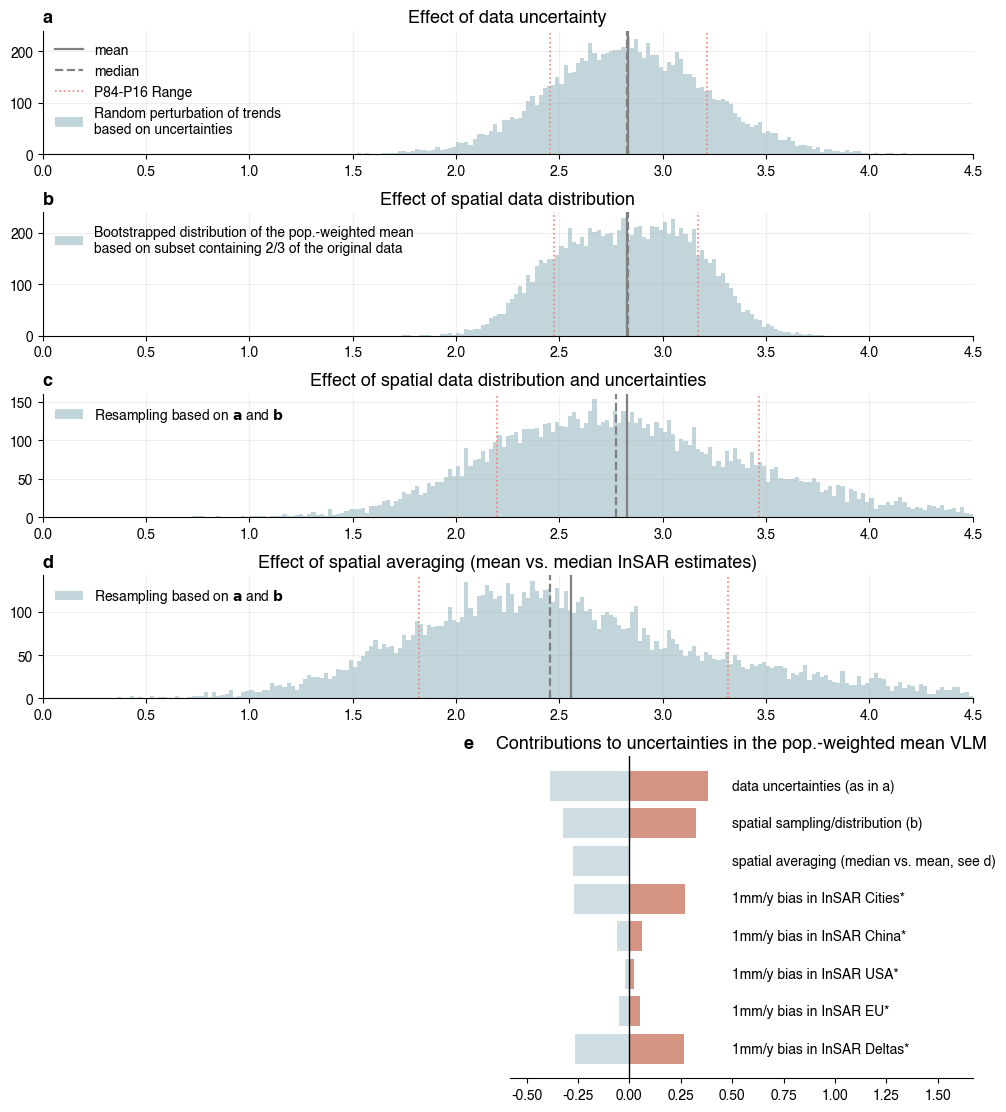

In [ ]:

ds_grouped['pop_below_10p0_nonzero'] = copy.deepcopy(ds_grouped['pop_below_10p0'])
ds_grouped['pop_below_10p0_nonzero'][ds_grouped['pop_below_10p0']<1] =0.1

bootstrap_it = 10000
test_size=0.5

bins = np.arange(300) / 50

# --- set up figure with GridSpec ---
f = plt.figure(figsize=(max_width, max_width*1.2))
res = 32
gs = GridSpec(6*res, 1*res, figure=f, hspace=0.25)  # tweak hspace as you like

a4 = f.add_subplot(gs[0:int(0.7*res), :])                 # top
a0 = f.add_subplot(gs[1*res:int(1.7*res), :], sharex=a4)
a1 = f.add_subplot(gs[2*res:int(2.7*res), :], sharex=a4)
a2 = f.add_subplot(gs[3*res:int(3.7*res), :], sharex=a4)
a5 = f.add_subplot(gs[4*res:int(5.8*res), 16:])


# ---------------- a0 panel ----------------
means_ = bootstrap_wavg(
    ds_grouped['VLM_map_InSAR6_GIA'].fillna(0),
    ds_grouped['pop_below_10p0'].fillna(0).values,
    it=bootstrap_it,test_size=test_size
) * -1000.




MEAN_BIAS = [] # collect abs magnitudes of effects of different error sources on global mean estimates
MEAN_BIAS.append([np.average(ds_grouped['VLM_map_InSAR6_GIA'].fillna(0),weights = ds_grouped.pop_below_10p0_nonzero.fillna(0).values)*-1000,0])  


MEAN_BIAS.append([np.mean(means_),np.std(means_)]) # ERROR due to spatial data distribution

a0.hist(
    means_,
    alpha=0.5,
    bins=bins,
    label='Bootstrapped distribution of the pop.-weighted mean \n'
          'based on subset containing 2/3 of the original data',color=cmap_err(0.2),
)

median_ = np.median(means_)
mean_ = np.mean(means_)
p84 = np.percentile(means_, 84.1)
p16 = np.percentile(means_, 15.9)
a0.set_xlim(0, 4.5)

a4.set_title('Effect of data uncertainty', fontsize=main_fontsize)
a0.set_title('Effect of spatial data distribution', fontsize=main_fontsize)

a0.axvline(mean_,   color='gray',   lw=1.6)
a0.axvline(median_, color='gray',   lw=1.6, ls='--')
a0.axvline(p84,     color='salmon', lw=1.2, ls=':')
a0.axvline(p16,     color='salmon', lw=1.2, ls=':')
a0.set_title('b', loc='left', fontsize=main_fontsize, fontweight='bold')

handles, labels = a0.get_legend_handles_labels()
handles = handles[-1:] + handles[:-1]
labels  = labels[-1:] + labels[:-1]
leg = a0.legend(handles, labels, loc='upper left', frameon=False)
a0.grid(alpha=0.2)
sns.despine()

# ---------------- a4 panel ----------------
means_ = bootstrap_wavg_un(
    ds_grouped['VLM_map_InSAR6_GIA'].fillna(0),
    ds_grouped.pop_below_10p0_nonzero.values,
    ds_grouped['VLM_map_InSAR6_combined_uncertainty_GIA'].fillna(0),
    test_size=1,
    it=bootstrap_it
) * -1000.


MEAN_BIAS.append([np.mean(means_),np.std(means_)]) # ERROR due to data uncertainty


a4.hist(means_, alpha=0.5, bins=bins,color=cmap_err(0.2),
        label='Random perturbation of trends\nbased on uncertainties')
median_ = np.median(means_)
mean_ = np.mean(means_)
p84 = np.percentile(means_, 84.1)
p16 = np.percentile(means_, 15.9)

a4.axvline(mean_,   color='gray',   lw=1.6, label='mean')
a4.axvline(median_, color='gray',   lw=1.6, ls='--', label='median')
a4.axvline(p84,     color='salmon', lw=1.2, ls=':', label='P84-P16 Range')
a4.axvline(p16,     color='salmon', lw=1.2, ls=':')
a4.grid(alpha=0.2)
a4.set_title('a', loc='left', fontsize=main_fontsize, fontweight='bold')
leg = a4.legend(loc='upper left', frameon=False)
sns.despine()

# ---------------- a1 panel ----------------
means_ = bootstrap_wavg_un(
    ds_grouped['VLM_map_InSAR6_GIA'].fillna(0),
    ds_grouped.pop_below_10p0_nonzero.values,
    ds_grouped['VLM_map_InSAR6_combined_uncertainty_GIA'].fillna(0),
    it=bootstrap_it,test_size=test_size
) * -1000.


a1.hist(means_, alpha=0.5, bins=bins,color=cmap_err(0.2),
        label=r'Resampling based on $\mathbf{a}$ and $\mathbf{b}$')
median_ = np.median(means_)
mean_ = np.mean(means_)
p84 = np.percentile(means_, 84.1)
p16 = np.percentile(means_, 15.9)

a1.axvline(mean_,   color='gray',   lw=1.6)
a1.axvline(median_, color='gray',   lw=1.6, ls='--')
a1.axvline(p84,     color='salmon', lw=1.2, ls=':')
a1.axvline(p16,     color='salmon', lw=1.2, ls=':')
a1.grid(alpha=0.2)
a1.set_title('c', loc='left', fontsize=main_fontsize, fontweight='bold')
a1.set_title('Effect of spatial data distribution and uncertainties',
             fontsize=main_fontsize)
leg = a1.legend(loc='upper left', frameon=False)
sns.despine()

# ---------------- a2 panel ----------------
means_ = bootstrap_wavg_un(
    ds_grouped['VLM_map_InSAR6_median_GIA'].fillna(0),
    ds_grouped.pop_below_10p0_nonzero.values,
    ds_grouped['VLM_map_InSAR6_combined_uncertainty_GIA'].fillna(0),
    it=bootstrap_it
) * -1000.


MEAN_BIAS.append([np.mean(means_),abs(np.mean(means_)-MEAN_BIAS[0][0])]) # ERROR due to data uncertainty and spatial distr.


a2.hist(means_, alpha=0.5, bins=bins,color=cmap_err(0.2),
        label=r'Resampling based on $\mathbf{a}$ and $\mathbf{b}$')
median_ = np.median(means_)
mean_ = np.mean(means_)
p84 = np.percentile(means_, 84.1)
p16 = np.percentile(means_, 15.9)

a2.axvline(mean_,   color='gray',   lw=1.6)
a2.axvline(median_, color='gray',   lw=1.6, ls='--')
a2.axvline(p84,     color='salmon', lw=1.2, ls=':')
a2.axvline(p16,     color='salmon', lw=1.2, ls=':')
a2.grid(alpha=0.2)
a2.set_title('d', loc='left', fontsize=main_fontsize, fontweight='bold')
a2.set_title('Effect of spatial averaging (mean vs. median InSAR estimates)',
             fontsize=main_fontsize)
leg = a2.legend(loc='upper left', frameon=False)
sns.despine()

names_use =[]
for id in [0,2,3,4,6]:
    (name,std)=settings['datatypes_info'][str(id)]
    std = 1
    names_use.append(str(std)+'mm/y bias in '+name+'*')
    mean_bias = copy.deepcopy(ds_grouped['VLM_map_InSAR6_combined_uncertainty_GIA'].fillna(0).values*0)
    mean_bias[ds_grouped['datatype']==id]=std/1000.
    avgb = np.average(ds_grouped['VLM_map_InSAR6_GIA'].fillna(0)+mean_bias,weights = ds_grouped.pop_below_10p0_nonzero.fillna(0).values)*-1000
    MEAN_BIAS.append([avgb,abs(MEAN_BIAS[0][0]-avgb)])    
    print(name,abs(MEAN_BIAS[0][0]-avgb))


order = [2,1,3,4,5,6,7,8]
names = ['data uncertainties (as in a)',
         'spatial sampling/distribution (b)',
         'spatial averaging (median vs. mean, see d)'] + names_use

# reorder MEAN_BIAS and names
MEAN_BIAS_ordered = [MEAN_BIAS[i] for i in order]
names_ordered     = names[::-1]

base=0# MEAN_BIAS[0][0]
# take the values you want to plot (2nd column)
vals = [pair[1] for pair in MEAN_BIAS_ordered][::-1]

y_pos = range(len(vals))
maskz = np.ones(len(vals))
maskz[5]=0

# positive bars
a5.barh(y_pos, vals*maskz,left=base, color=cmap_err(0.8))
# negative bars (mirrored)
a5.barh(y_pos, [-v for v in vals],left=base, color=cmap_err(0.2), alpha=0.4)
# labels
a5.set_yticks(y_pos)
a5.set_yticklabels(names_ordered)
# center line
a5.axvline(0, color='black', lw=1)
a5.set_yticks([])
a5.set_yticklabels([])

a5.set_title('Contributions to uncertainties in the pop.-weighted mean VLM', fontsize=main_fontsize)
a5.set_title('e', loc='left',x=-0.1  , fontsize=main_fontsize, fontweight='bold')


for y, name in zip(y_pos, names_ordered):
    a5.text(
        base + 0.5,   # small offset to the right of baseline
        y,
        name,
        va='center',
        ha='left',
        fontsize=10
    )

a5.spines['left'].set_visible(False)

xmin, xmax = a4.get_xlim()
a5.set_xlim((xmin + xmax) / 2-MEAN_BIAS[0][0], xmax-MEAN_BIAS[0][0])

plt.tight_layout()
plt.savefig(settings['plot_ext'] + 'SI7.png',bbox_inches='tight')
plt.savefig(settings['plot_ext'] + 'SI7.pdf',bbox_inches='tight')

plt.show()

In [6]:
for v,n in zip(vals,names_ordered):
    print(n,v)

1mm/y bias in InSAR Deltas* 0.26390236537510425
1mm/y bias in InSAR EU* 0.05160166752410511
1mm/y bias in InSAR USA* 0.020330797979264403
1mm/y bias in InSAR China* 0.060254420088950766
1mm/y bias in InSAR Cities* 0.2701215191604791
spatial averaging (median vs. mean, see d) 0.27698751929052046
spatial sampling/distribution (b) 0.32328082892374127
data uncertainties (as in a) 0.38392903067114614


In [16]:
print(ds_grouped['VLM_map_InSAR6_combined_uncertainty_GIA'][~(ds_grouped['c Delta subsidence only']==0)].median())
print(ds_grouped['VLM_map_InSAR6_combined_uncertainty_GIA'][~(ds_grouped['d City subsidence only']==0)].median())
print(ds_grouped['VLM_map_InSAR6_combined_uncertainty_GIA'][(ds_grouped['c Delta subsidence only']==0) & (ds_grouped['d City subsidence only']==0) ].median())

<xarray.DataArray 'VLM_map_InSAR6_combined_uncertainty_GIA' ()>
array(0.00184379)
<xarray.DataArray 'VLM_map_InSAR6_combined_uncertainty_GIA' ()>
array(0.00261709)
<xarray.DataArray 'VLM_map_InSAR6_combined_uncertainty_GIA' ()>
array(0.00088877)


# SI plot: Countries

# Density ETC

In [ ]:
station_weights = xr.open_dataset(settings['data_in']+'NGL_GNSS/data_station_density_Cleaned_ym_min3M_demeaned.nc')
# File with station density

station_weights_res = station_weights*((np.pi*(500)*2)/100.)
station_weights_res = (station_weights_res/((np.pi*(500)**2)/10000.))
#ds_grouped = data
dat_pop = ds_grouped['pop_below_10p0'][ds_grouped.lat<83]
# first round
st_cop1,pop_cop1 = sl(station_weights_res.x).couple(dat_pop.x,limit=100)
dat_pop2=dat_pop.sel({'x':~np.isin(dat_pop.x.values,pop_cop1.data.dropna(dim='x').astype(int))})
st_cop2,pop_cop2 = sl(station_weights_res.x).couple(dat_pop2.x,limit=10000)
dens_selected = np.append(station_weights_res['U_sub_offset_ann'][st_cop1.data.dropna(dim='x').values.astype(int)],
                              station_weights_res['U_sub_offset_ann'][st_cop2.data.dropna(dim='x').values.astype(int)])
pop_selected = np.append(dat_pop.values[pop_cop1.data.dropna(dim='x').values.astype(int)],
              dat_pop2.values[pop_cop2.data.dropna(dim='x').values.astype(int)])

nearest
x
100
nearest
x
10000


4 InSAR EU 1.19
3 InSAR USA 1.43
1 InSAR NZ 1.6
0 InSAR Cities 1.72
6 InSAR Deltas 1.2
2 InSAR China 1.5
5 GNSS 0
8 OE24 0
9 GIA 0


/home/oelsmann/.conda/envs/vlad_py37/lib/python3.6/site-packages/ipykernel_launcher.py:164: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations


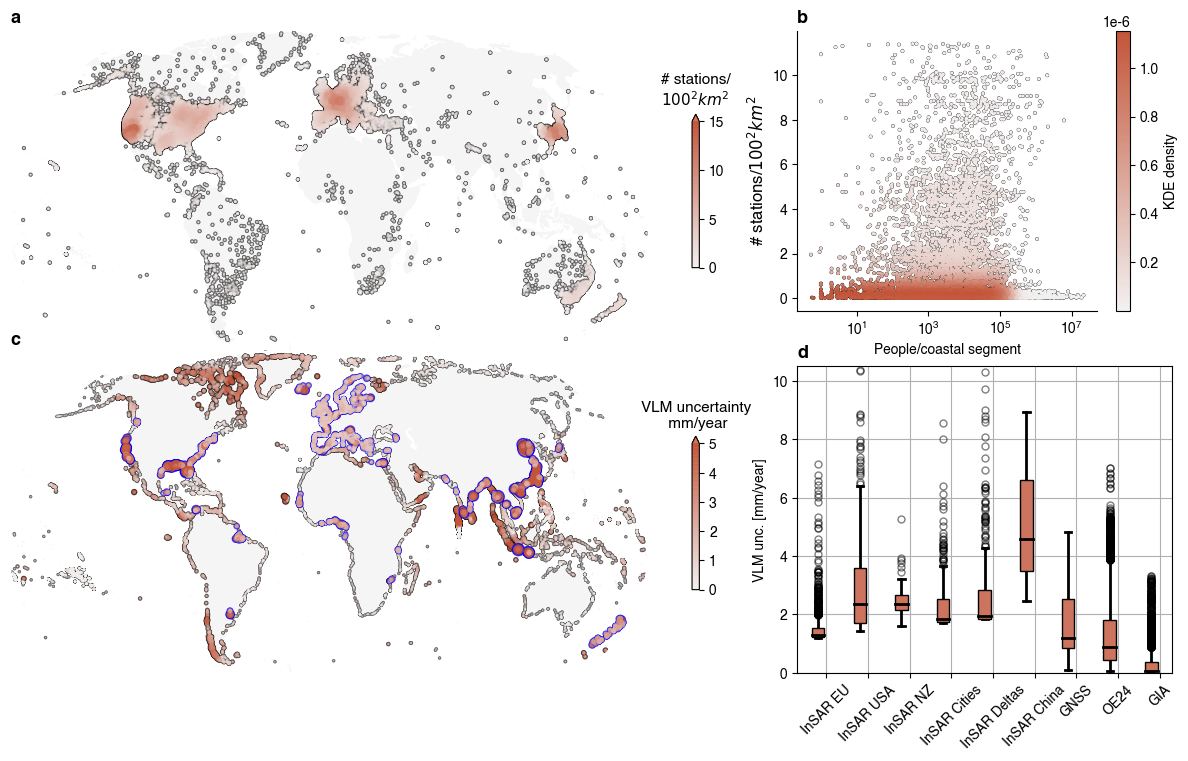

In [ ]:

proj = ccrs.Robinson()

fig = plt.figure(figsize=(16,8.5))
factor=3
number_of_plots = 2
xp = 2
yp=2
gs = gridspec.GridSpec(16*factor, 12*factor)


limits_ = [[-0.008,0.008],[-0.008,0.008],[-0.008,0.008],[10**1,10**8]]
units = ['mm/year','mm/year','mm/year','people']
cbar_extends = ['both','both','both','max']

ii=0
jj=0
 
scatter_kws = {}
limits = [0,15]
factorm =1
scaler_factor=1
cbar_extend = 'max'
unit='# stations/\n'+ r'$100^2km^2$'
lblbl = 'a'

cmap_err = sns.diverging_palette(220, 20, as_cmap=True)

# sample 256 colors from the upper half only
upper = cmap_err(np.linspace(0.5, 1.0, 256))
upper = LinearSegmentedColormap.from_list("cmap_err_upper", upper)

ax = fig.add_subplot(gs[int(1*16/xp*factor):int((1+1)*16/xp*factor),int(jj*12/yp*factor):int((1.45)*12/yp*factor)],projection = proj)
limits = [0,5]

size_map =2

ax,im = plot_map_ax_mapping(ax,ds_grouped['VLM_map_InSAR6_combined_uncertainty_GIA'].dropna(dim='x',how='all')*1000.,region='custom',
                            msize=size_map,land_facecolor='whitesmoke',aspect=1.15,edgecolor=['k'],
            scalecolor=True,label='',extend=[-179,179,-60,85],minv = limits[0]*factorm,maxv = limits[1]*factorm,alpha=0.8,alpha_overlay=.4,
                color_map=upper,gltop=False,glleft=False,scaler_factor=scaler_factor,
                glbottom=True,glright=False,overlay_ocean=False,draw_gridlines=False,scatter_kws=scatter_kws) 


ax,im = plot_map_ax_mapping(ax,ds_grouped['VLM_map_InSAR6_combined_uncertainty_GIA'][~np.isnan(ds_grouped['VLM_InSAR3.03'])].dropna(dim='x',how='all')*1000.,region='custom',
                            msize=size_map*2.3,land_facecolor='whitesmoke',aspect=1.15,edgecolor=['blue'],
            scalecolor=True,label='',extend=[-179,179,-60,85],minv = limits[0]*factorm,maxv = limits[1]*factorm,alpha=0.8,alpha_overlay=.4,
                color_map=upper,gltop=False,glleft=False,scaler_factor=scaler_factor,
                glbottom=True,glright=False,overlay_ocean=False,draw_gridlines=False,scatter_kws=scatter_kws) 



clb =plt.colorbar(im,ax=ax, shrink=.48,extend=cbar_extend,orientation='vertical')

clb.ax.set_title('VLM uncertainty\n mm/year',fontsize=11)
ax.set_rasterized('rasterized')
ax.set_title('c',loc='left',fontsize=main_fontsize,fontweight="bold") 
ax.set_title('',loc='center',fontsize=main_fontsize) 
ax.axis('off')
limits = [0,15]



ax = fig.add_subplot(gs[int(ii*16/xp*factor):int((ii+1)*16/xp*factor),int(jj*12/yp*factor):int((1.45)*12/yp*factor)],projection = proj)
version = 'v2'
size_map = 4
size_scatter = 2
scatter_kws = {}



ax,im = plot_map_ax_mapping(ax,station_weights_res['U_sub_offset_ann'].dropna(dim='x',how='all'),region='custom',
                            msize=size_map,land_facecolor='whitesmoke',aspect=1.15,edgecolor=['k'],
            scalecolor=True,label='',extend=[-179,179,-60,85],minv = limits[0]*factorm,maxv = limits[1]*factorm,alpha=0.8,alpha_overlay=.4,
                color_map=upper,gltop=False,glleft=False,scaler_factor=scaler_factor,
                glbottom=True,glright=False,overlay_ocean=False,draw_gridlines=False,scatter_kws=scatter_kws) 


clb =plt.colorbar(im,ax=ax, shrink=.48,extend=cbar_extend,orientation='vertical')
clb.ax.set_title(unit,fontsize=11)
ax.set_rasterized('rasterized')
ax.set_title(lblbl,loc='left',fontsize=main_fontsize,fontweight="bold") 
ax.set_title('',loc='center',fontsize=main_fontsize) 

ii=0


ax.axis('off')


ax = fig.add_subplot(gs[int(0*16/xp*factor):int((0.9)*16/xp*factor),int((1.4)*12/yp*factor):int((2)*12/yp*factor)])
ax.set_title('b',loc='left',fontsize=main_fontsize,fontweight="bold") 


x = pop_selected[pop_selected>0]
y = dens_selected[pop_selected>0]

# Calculate the point density
xy = np.vstack([x,y])
z = gaussian_kde(xy)(xy)
sc = ax.scatter(x, y, c=z, s=3,cmap=upper,edgecolor='k')
ax.scatter(x, y, c=z, s=2,cmap=upper)
ax.set_xscale('log')
sns.despine()
ax.set_ylabel(r'# stations/$100^2km^2$',fontsize=12)
ax.set_xlabel('People/coastal segment')
cb = plt.colorbar(sc, ax=ax, label='KDE density')


ax = fig.add_subplot(gs[int(1.05*16/xp*factor):int((1+1)*16/xp*factor),int((1.4)*12/yp*factor):int((2)*12/yp*factor)])


i=0

varname = "VLM_map_InSAR6_combined_uncertainty_GIA"

data_for_boxes = []
labels = []

for k in [4,3,1,0,6,2,5,8,9]:
    name, value = settings['datatypes_info'][str(k)]
    print(k, name, value)
    # Boolean mask for this datatype
    mask = ds_grouped['datatype'] == int(k)

    # Extract values for this datatype, drop NaNs, flatten
    vals = ds_grouped[varname].where(mask).values.ravel()
    vals = vals[~np.isnan(vals)]*1000.

    # Skip if empty (just in case)
    if vals.size == 0:
        continue

    data_for_boxes.append(vals)
    labels.append(name)

    boxplot = ax.boxplot(vals,positions =[i-0.2],widths=0.3,boxprops ={'color':'k','linewidth':1},
            medianprops={'color':'k','linewidth':2},
            whiskerprops={'color':'k','linewidth':2},capprops={'color':'k','linewidth':2} ,patch_artist=True,flierprops={'markersize':5,'alpha':0.5})
    boxplot['boxes'][0].set_facecolor(cmap_err(0.9))

    i=i+1

ax.grid()
ax.set_xticks(np.arange(i))
ax.set_xticklabels(labels, rotation=45,fontsize=10)
ax.set_ylim(0,10.5)
ax.set_ylabel('VLM unc. [mm/year]')
ax.set_title('d',loc='left',fontsize=main_fontsize,fontweight="bold") 

plt.savefig(settings['plot_ext'] + 'SI6.png',bbox_inches='tight')
plt.savefig(settings['plot_ext'] + 'SI6.pdf',bbox_inches='tight')

plt.tight_layout()
plt.show()

